# 06 — Классификатор дампов (зеркало pump-13)

Не все −7% дампы отскакивают одинаково. Идея (как в pump-13): по ПРИЧИННЫМ
фичам в момент **первого триггера** предсказать, насколько хорош будет отскок,
и торговать только те дампы, что модель любит.

**Honest сетап:**
- Фичи вычисляются на баре первого триггера `st` по данным ≤ st (lookahead-free).
- Метка = scale-in net PnL события (то, что меряли в iter02-05).
- Модель = HistGradientBoostingRegressor. Time-split: train = первые 60% событий
  по времени, test = последние 40% (честный OOS, без перемешивания).
- Метрики OOS: corr(pred, actual), монотонность по децилям, «торговать топ-50%
  по предсказанию» vs «торговать всё».
- Сохраняю таблицу сделок с фичами → используется в 07 (compounding).

Порог −7%/15m, полная вселенная 173.

In [1]:
import sys; sys.path.insert(0,".")
from _lab import *
import numpy as np, pandas as pd
from pathlib import Path

WIN=15;H=240;COOLDOWN=10;MIN_GAP=3;N_MAX=10;FEE=0.00075;THR=0.07
DAY=1440
ALLSYMS=list_symbols()

def clusters(c,thr):
    if len(c)<WIN+5: return []
    r=np.full(len(c),np.nan); r[WIN:]=c[WIN:]/c[:-WIN]-1
    cond=r<=-thr; out=[]; i=WIN; n=len(c)
    while i<n:
        if not cond[i] or (i>0 and cond[i-1]): i+=1; continue
        start=i;last_true=i;tr=[i];lastt=i;falses=0;j=i+1
        while j<n:
            if cond[j]:
                last_true=j;falses=0
                if j-lastt>=MIN_GAP and len(tr)<N_MAX: tr.append(j);lastt=j
            else:
                falses+=1
                if falses>=COOLDOWN: break
            j+=1
        out.append((start,last_true,tr)); i=last_true+COOLDOWN+1
    return out

def features(c,v,h,l,st):
    # all use data up to st (inclusive) -> causal
    def ret(k): return c[st]/c[st-k]-1 if st-k>=0 else np.nan
    r1,r3,r5,r15,r30,r60 = ret(1),ret(3),ret(5),ret(15),ret(30),ret(60)
    recent5 = c[st]/c[st-5]-1
    prev10  = c[st-5]/c[st-15]-1 if st-15>=0 else np.nan
    accel   = recent5-prev10            # >0 dump decelerating, <0 accelerating
    vol15   = v[st-14:st+1].sum()
    base    = np.median(v[max(0,st-DAY):st]) if st> 60 else np.nan
    surge15 = vol15/(base*15) if base and base>0 else np.nan
    surge1  = v[st]/base if base and base>0 else np.nan
    lr      = np.diff(np.log(c[max(0,st-60):st+1]))
    volreg  = lr.std() if len(lr)>5 else np.nan
    rng15   = (h[st-14:st+1].max()-l[st-14:st+1].min())/c[st]
    hi_d    = c[st]/h[max(0,st-DAY):st+1].max()-1     # dist from day high (<=0)
    lo_d    = c[st]/l[max(0,st-DAY):st+1].min()-1     # dist from day low (>=0)
    # down streak
    ds=0; k=st
    while k>0 and c[k]<c[k-1]: ds+=1; k-=1
    return dict(r1=r1,r3=r3,r5=r5,r15=r15,r30=r30,r60=r60,accel=accel,
                surge15=surge15,surge1=surge1,volreg=volreg,rng15=rng15,
                hi_d=hi_d,lo_d=lo_d,dstreak=ds)

rows=[]; loaded=0
for s in ALLSYMS:
    try: df=ohlcv(s,"2024-01-01","2026-07-01","1min")
    except Exception: continue
    c=df["close"].to_numpy("float64"); v=df["volume"].to_numpy("float64")
    h=df["high"].to_numpy("float64"); l=df["low"].to_numpy("float64")
    ts=df.index; n=len(c); loaded+=1
    for (st,en,tr) in clusters(c,THR):
        ex=en+1+H
        if st<DAY or st+1>=n or ex>=n: continue   # need 1d history + measurable exit
        prices=np.array([c[t+1] for t in tr if t+1<n])
        ws=np.arange(1,len(prices)+1,dtype=float); ws/=ws.sum()
        avg=(ws*prices).sum()
        feat=features(c,v,h,l,st)
        feat.update(sym=s, entry=ts[st+1], exit_ts=ts[ex], ntr=len(prices),
                    pnl=c[ex]/avg-1-2*FEE)
        rows.append(feat)
    if loaded%25==0: print(f"  loaded {loaded}")
D=pd.DataFrame(rows).dropna().sort_values("entry").reset_index(drop=True)
print(f"\nevents with full features: {len(D)}  (need 1d history => early ones dropped)")
print("base per-trade pnl: mean %.3f%%  win %.1f%%" % (D.pnl.mean()*100,(D.pnl>0).mean()*100))

  loaded 25


  loaded 50


  loaded 75


  loaded 100


  loaded 125


  loaded 150



events with full features: 4286  (need 1d history => early ones dropped)
base per-trade pnl: mean 4.066%  win 71.1%


In [2]:
from sklearn.ensemble import HistGradientBoostingRegressor
FEATS=["r1","r3","r5","r15","r30","r60","accel","surge15","surge1","volreg","rng15","hi_d","lo_d","dstreak"]
split=int(len(D)*0.60)
tr=D.iloc[:split]; te=D.iloc[split:]
print(f"train {len(tr)} (to {tr.entry.max():%Y-%m-%d})  |  test {len(te)} ({te.entry.min():%Y-%m-%d}..{te.entry.max():%Y-%m-%d})")
m=HistGradientBoostingRegressor(max_depth=3,learning_rate=0.05,max_iter=400,
                                l2_regularization=1.0,min_samples_leaf=40,random_state=0)
m.fit(tr[FEATS],tr.pnl)
te=te.copy(); te["pred"]=m.predict(te[FEATS])
corr=np.corrcoef(te.pred,te.pnl)[0,1]
print(f"\nOOS corr(pred, actual pnl) = {corr:+.3f}")

train 2571 (to 2025-02-02)  |  test 1715 (2025-02-02..2026-04-27)



OOS corr(pred, actual pnl) = +0.117


In [3]:
# decile monotonicity on TEST
te["dec"]=pd.qcut(te.pred,10,labels=False,duplicates="drop")
g=te.groupby("dec").agg(n=("pnl","size"),mean_pnl=("pnl","mean"),win=("pnl",lambda x:(x>0).mean()))
print("=== TEST deciles by model prediction (worst->best) ===")
for d,row in g.iterrows():
    print(f"  dec {int(d):>2}: n={int(row.n):4d}  mean pnl {row.mean_pnl*100:+6.2f}%  win {row.win*100:4.1f}%")

=== TEST deciles by model prediction (worst->best) ===
  dec  0: n= 172  mean pnl  +3.08%  win 50.0%
  dec  1: n= 171  mean pnl  +1.40%  win 55.0%
  dec  2: n= 172  mean pnl  +2.72%  win 55.8%
  dec  3: n= 171  mean pnl  +3.21%  win 59.1%
  dec  4: n= 172  mean pnl  +5.81%  win 71.5%
  dec  5: n= 171  mean pnl  +6.50%  win 72.5%
  dec  6: n= 171  mean pnl  +4.39%  win 71.9%
  dec  7: n= 172  mean pnl  +5.29%  win 73.8%
  dec  8: n= 171  mean pnl  +7.23%  win 76.6%
  dec  9: n= 172  mean pnl  +9.24%  win 83.7%


In [4]:
# trade-all vs trade top-50% (pred>median) vs top-30%, on TEST, net
def summ(a):
    a=np.array(a); return (len(a),a.mean()*100,np.median(a)*100,(a>0).mean()*100,
                           a.mean()/a.std() if a.std()>0 else np.nan)
med=te.pred.median(); q70=te.pred.quantile(0.70); pos=te.pred>0
print("=== TEST per-trade, net (entry +1, scale-in) ===")
for tag,mask in [("trade ALL",np.ones(len(te),bool)),
                 ("pred > 0",pos.values),
                 ("top 50% (pred>median)",(te.pred>med).values),
                 ("top 30% (pred>q70)",(te.pred>q70).values)]:
    n,mn,md_,w,ms=summ(te.pnl[mask])
    print(f"  {tag:24} n={n:4d}  mean {mn:+5.2f}%  med {md_:+5.2f}%  win {w:4.1f}%  m/std {ms:+.3f}")

=== TEST per-trade, net (entry +1, scale-in) ===
  trade ALL                n=1715  mean +4.89%  med +2.49%  win 67.0%  m/std +0.374
  pred > 0                 n=1297  mean +5.76%  med +3.27%  win 72.2%  m/std +0.435
  top 50% (pred>median)    n= 857  mean +6.53%  med +4.12%  win 75.7%  m/std +0.503
  top 30% (pred>q70)       n= 515  mean +7.25%  med +5.37%  win 78.1%  m/std +0.573


=== permutation importance (test, drop in R^2) ===
  r60       +0.1781
  r5        +0.0195
  r3        +0.0178
  rng15     +0.0169
  dstreak   +0.0133
  r30       +0.0115
  r15       +0.0019
  lo_d      -0.0016
  r1        -0.0019
  volreg    -0.0079
  surge15   -0.0227
  surge1    -0.0307
  hi_d      -0.0337
  accel     -0.0380
[saved] notebooks\dump\_out\06_classifier.png


WindowsPath('C:/projects/researchlab/notebooks/dump/_out/06_classifier.png')

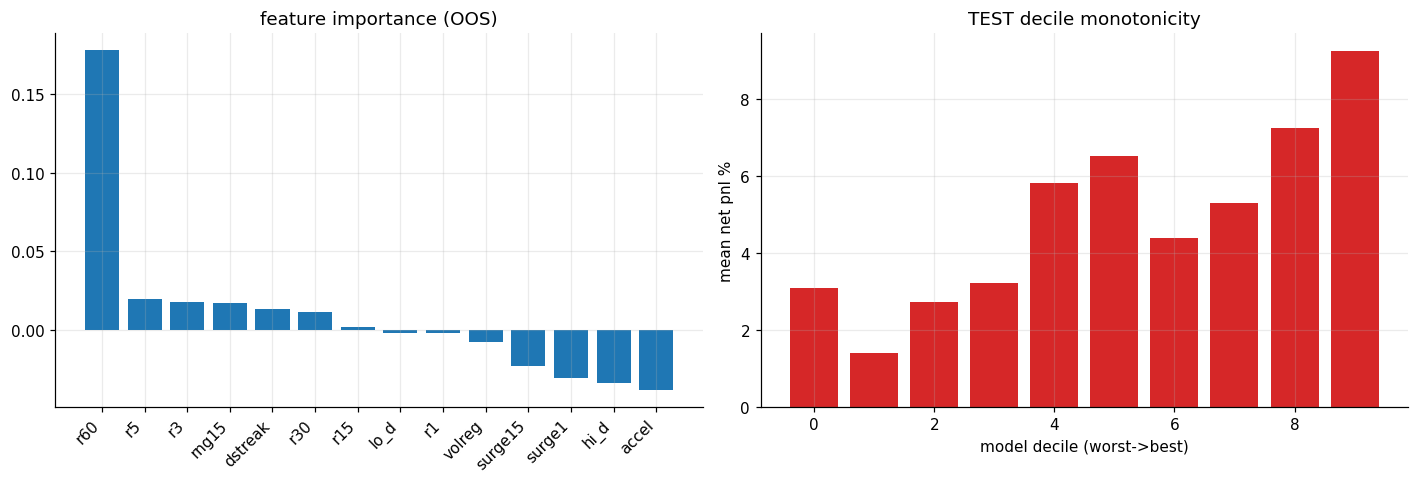

In [5]:
# feature importance via permutation on TEST
from sklearn.inspection import permutation_importance
pi=permutation_importance(m,te[FEATS],te.pnl,n_repeats=8,random_state=0,scoring="r2")
imp=pd.Series(pi.importances_mean,index=FEATS).sort_values(ascending=False)
print("=== permutation importance (test, drop in R^2) ===")
for k,val in imp.items(): print(f"  {k:9} {val:+.4f}")

import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
ax[0].bar(range(len(imp)),imp.values,color="#1f77b4"); ax[0].set_xticks(range(len(imp)))
ax[0].set_xticklabels(imp.index,rotation=45,ha="right"); ax[0].set_title("feature importance (OOS)")
ax[1].bar(g.index,g.mean_pnl*100,color="#d62728"); ax[1].axhline(0,color="k",lw=.6)
ax[1].set_xlabel("model decile (worst->best)"); ax[1].set_ylabel("mean net pnl %")
ax[1].set_title("TEST decile monotonicity")
show("06_classifier")

In [6]:
# refit on ALL data, save model + trades-with-pred table for nb07 (compounding)
import joblib
m_all=HistGradientBoostingRegressor(max_depth=3,learning_rate=0.05,max_iter=400,
            l2_regularization=1.0,min_samples_leaf=40,random_state=0)
# IMPORTANT: for the filtered portfolio in 07, use WALK-FORWARD preds (no lookahead):
# pred for each event from a model trained only on EARLIER events. Approx with the
# single 60/40 split -> only TEST has honest preds. Save full table + test preds.
D.to_parquet(Path("_out")/"dump_trades.parquet")
te[["sym","entry","exit_ts","pnl","pred"]].to_parquet(Path("_out")/"dump_test_pred.parquet")
print("saved _out/dump_trades.parquet (%d rows) and dump_test_pred.parquet (%d rows)"%(len(D),len(te)))

saved _out/dump_trades.parquet (4286 rows) and dump_test_pred.parquet (1715 rows)

## Как читать
- **OOS corr** — связь предсказания и реального PnL на тесте (вне обучения).
  В pump-13 было +0.30; любая стабильно положительная = модель что-то ловит.
- **Децили** — если средний PnL растёт от худшего дециля к лучшему = модель
  ранжирует дампы по качеству отскока. Монотонность важнее величины corr.
- **trade-all vs top-X%** — практический выигрыш: если топ по предсказанию даёт
  заметно выше per-trade и m/std, фильтр работает.
- **Важно (honest):** это ОДИН time-split (как pump-13). Walk-forward (4 фолда) =
  отдельный шаг (pump-14). Фичи r15 почти константа по построению (≤−7%).

*Verdict после прогона.*

## VERDICT (iter 06)

**Классификатор работает OOS (зеркало pump-13).** Фичи на баре первого триггера
(causal), метка = scale-in net PnL, time-split 60/40.
- OOS corr +0.117 (скромнее pump +0.30, но устойчиво >0). Децили монотонны:
  худший +1.4% → лучший +9.24% (win 83.7%).
- Фильтр OOS: trade-all +4.89% (win 67%, m/std 0.374) → top-30% +7.25% (win 78%,
  **m/std 0.573**); top-50% +6.53% (0.503); pred>0 +5.76% (0.435).
- Топ-фичи: r60 (доминирует), r5, r3, rng15, dstreak. surge/accel/hi_d бесполезны
  (отриц. важность) — выкинуть позже.

**Оговорки:** один time-split (нужен walk-forward, pump-14); тестовая эпоха
сильнее (абсолют +4.89% завышен vs 2024 ~+3.4%) → реальный сигнал в ОТНОСИТЕЛЬНОМ
превосходстве фильтра. r15 ~константа по построению.

Сохранены _out/dump_trades.parquet, dump_test_pred.parquet → для iter07.
**Дальше:** walk-forward валидация фильтра; compounding (iter07).